# **Penerapan Word2Vec pada Data Teks Bahasa Indonesia**

Notebook ini membahas penggunaan **Word2Vec Skip-gram** untuk mengubah kata dalam berita hasil scraping menjadi vektor numerik, kemudian menggunakan vektor dokumen untuk klasifikasi kategori `sport` dan `finance`. Materi dimulai dari contoh kecil tentang pasangan kata target-konteks, lalu berlanjut ke preprocessing, lima variasi eksperimen, tuning parameter, evaluasi, penyimpanan model, dan tautan aplikasi demo.

Alur notebook:

1. Memahami konsep Word2Vec, Skip-gram, dan CBOW melalui contoh sederhana.
2. Memeriksa serta mengeksplorasi dataset berita hasil scraping.
3. Membentuk token dengan beberapa konfigurasi preprocessing.
4. Melatih embedding Skip-gram dan merangkum vektor kata menjadi vektor dokumen.
5. Menguji kombinasi parameter Word2Vec dan Gaussian Naive Bayes, lalu membandingkan lima skenario preprocessing.
6. Melatih model final, melihat contoh representasi dokumen, dan menyimpan model yang dipilih.

Bag of Words dan TF-IDF terutama merepresentasikan kemunculan atau bobot kata pada dokumen. Word2Vec mempelajari vektor kata dari pola konteks: kata yang muncul dalam konteks serupa diharapkan memiliki representasi yang berdekatan. Vektor kata selanjutnya dirata-ratakan agar setiap artikel memiliki fitur berdimensi tetap untuk classifier.

In [2]:
from gensim.models import Word2Vec

In [3]:
kalimat = [
    ["pemerintah", "menaikkan", "harga", "saham", "pasar", "keuangan"],
    ["investor", "membeli", "saham", "perusahaan", "teknologi", "pasar"],
    ["atlet", "meraih", "medali", "emas", "dalam", "kompetisi", "olahraga"]
]

In [4]:
# 2. Atur parameter yang ingin Anda uji coba
n_vector = 10     # Dimensi vektor (bebas diganti, misal: 5, 10, 50, 100)
window_size = 5   # Ukuran window konteks (bebas diganti, misal: 1, 2, 3)

### Memahami Data Contoh dan Parameter

Data `kalimat` berupa daftar kalimat yang sudah ditokenisasi: setiap kalimat adalah list kata, sehingga batas antarkalimat tetap diketahui oleh Gensim. Contohnya, dua kalimat pertama membahas pasar dan saham, sedangkan kalimat ketiga berisi konteks olahraga.

`vector_size` menentukan banyaknya angka pada vektor setiap kata. Pada contoh ini nilainya 10, jadi sebuah kata direpresentasikan oleh 10 angka yang dipelajari model. `window` menentukan seberapa jauh kata di kiri dan kanan menjadi konteks bagi kata target. Dengan `window_size=5` dan kalimat contoh yang hanya berisi 6 atau 7 kata, hampir semua kata lain dalam kalimat menjadi konteks. Ini memudahkan ilustrasi, tetapi korpus sekecil ini belum cukup untuk menghasilkan embedding yang kuat atau stabil.

In [5]:
# 3. Membuat dan melatih model Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=kalimat,
    vector_size=n_vector,
    window=window_size,
    sg=1,          # sg=1 untuk Skip-gram (sg=0 untuk CBOW)
    min_count=1,   # min_count=1 agar semua kata ikut dihitung
    workers=1,
    seed=42
)

### Cara Kerja Word2Vec Skip-gram

Word2Vec belajar membuat vektor kata dengan menggunakan konteks di sekitarnya sebagai sinyal pembelajaran. Pada **Skip-gram**, satu kata target digunakan untuk memprediksi kata-kata konteksnya. Secara intuitif, model berusaha memperbesar peluang kata konteks yang benar muncul di sekitar target.

Jika `w` adalah kata target dan `c` adalah kata konteks, bentuk softmax sederhananya dapat ditulis:

$$P(c \mid w) = \frac{\exp(\mathbf{u}_c^{\mathsf{T}}\mathbf{v}_w)}{\sum_{c' \in V} \exp(\mathbf{u}_{c'}^{\mathsf{T}}\mathbf{v}_w)}$$

`V` adalah vocabulary, `v_w` vektor target, dan `u_c` vektor konteks. Pelatihan menyesuaikan vektor agar konteks yang benar lebih mudah diprediksi. Implementasi praktis Gensim menggunakan strategi training yang efisien; persamaan ini membantu menjelaskan tujuannya, bukan langkah hitung literal untuk setiap parameter.

Pada pemanggilan `Word2Vec`, `sg=1` memilih Skip-gram, `min_count=1` mempertahankan semua kata pada contoh, dan `seed` mengatur inisialisasi acak agar percobaan lebih mudah diulang. Dengan data yang sangat sedikit, vektor hanya contoh hasil belajar dan belum merepresentasikan makna bahasa secara andal.

In [6]:
def ekstrak_kombinasi_skipgram(kalimat_list, window_size):
    pasangan_kombinasi = []
    
    for kalimat in kalimat_list:
        panjang_kalimat = len(kalimat)
        for i, kata_target in enumerate(kalimat):
            # Tentukan jangkauan jendela di kiri dan kanan
            awal = max(0, i - window_size)
            akhir = min(panjang_kalimat, i + window_size + 1)
            
            for j in range(awal, akhir):
                if i != j:  # Abaikan jika indeksnya sama dengan kata target
                    kata_konteks = kalimat[j]
                    pasangan_kombinasi.append((kata_target, kata_konteks))
                    
    return pasangan_kombinasi

### Membentuk Pasangan Target dan Konteks

Fungsi `ekstrak_kombinasi_skipgram` membuat ilustrasi pasangan dengan mengunjungi setiap posisi kata sebagai target, lalu mengambil kata lain dalam rentang window sebagai konteks. `max` dan `min` menjaga batas window agar tidak melewati awal atau akhir kalimat, sedangkan syarat `i != j` mencegah kata menjadi konteks dirinya sendiri.

Pasangan bersifat berarah: `(saham, pasar)` berarti `saham` sebagai target dan `pasar` sebagai konteks; pasangan arah sebaliknya dibuat ketika posisi `pasar` dikunjungi. Setelah itu, `set` menghapus pasangan yang sama untuk menampilkan daftar unik. Langkah penghapusan duplikat ini hanya untuk ringkasan contoh. Dalam training, jumlah kemunculan dan konteks yang terbentuk dari korpus tetap menjadi sinyal belajar, bukan sekadar daftar pasangan unik.

Dengan window 5 pada kalimat-kalimat pendek di atas, sebagian besar kata lain dalam kalimat masuk sebagai konteks. Pada korpus berita, ukuran window lebih kecil atau lebih besar akan mengubah jenis hubungan lokal yang dipelajari model.

In [7]:
# 1. Ekstrak seluruh pasangan berdasarkan window_size
semua_pasangan = ekstrak_kombinasi_skipgram(kalimat, window_size=window_size)

# 2. Ambil hanya kombinasi pasangan yang UNIK (menghilangkan duplikat)
kombinasi_unik = sorted(list(set(semua_pasangan)))

# 3. Tampilkan Hasil
print(f"=== IDENTIFIKASI KOMBINASI KATA (window={window_size}) ===")
print(f"Total pasangan terbentuk     : {len(semua_pasangan)}")
print(f"Total pasangan KATA UNIK     : {len(kombinasi_unik)}\n")

print("Daftar Kombinasi Kata Unik (Target -> Konteks):")
for target, konteks in kombinasi_unik:
    print(f"Target: '{target}'  -->  Konteks: '{konteks}'")

=== IDENTIFIKASI KOMBINASI KATA (window=5) ===
Total pasangan terbentuk     : 100
Total pasangan KATA UNIK     : 98

Daftar Kombinasi Kata Unik (Target -> Konteks):
Target: 'atlet'  -->  Konteks: 'dalam'
Target: 'atlet'  -->  Konteks: 'emas'
Target: 'atlet'  -->  Konteks: 'kompetisi'
Target: 'atlet'  -->  Konteks: 'medali'
Target: 'atlet'  -->  Konteks: 'meraih'
Target: 'dalam'  -->  Konteks: 'atlet'
Target: 'dalam'  -->  Konteks: 'emas'
Target: 'dalam'  -->  Konteks: 'kompetisi'
Target: 'dalam'  -->  Konteks: 'medali'
Target: 'dalam'  -->  Konteks: 'meraih'
Target: 'dalam'  -->  Konteks: 'olahraga'
Target: 'emas'  -->  Konteks: 'atlet'
Target: 'emas'  -->  Konteks: 'dalam'
Target: 'emas'  -->  Konteks: 'kompetisi'
Target: 'emas'  -->  Konteks: 'medali'
Target: 'emas'  -->  Konteks: 'meraih'
Target: 'emas'  -->  Konteks: 'olahraga'
Target: 'harga'  -->  Konteks: 'keuangan'
Target: 'harga'  -->  Konteks: 'menaikkan'
Target: 'harga'  -->  Konteks: 'pasar'
Target: 'harga'  -->  Konteks: '

In [8]:
# 4. Menampilkan hasil vektor angka untuk kata "saham"
kata_uji = "saham"
vektor_kata = model_skipgram.wv[kata_uji]

In [9]:
print(f"=== HASIL SKIIP-GRAM (n={n_vector}, window={window_size}) ===")
print(f"Ukuran dimensi vektor '{kata_uji}': {vektor_kata.shape[0]}")
print(f"Vektor angka untuk kata '{kata_uji}':\n{vektor_kata}\n")

=== HASIL SKIIP-GRAM (n=10, window=5) ===
Ukuran dimensi vektor 'saham': 10
Vektor angka untuk kata 'saham':
[ 0.00530819  0.09512772  0.04711951  0.05224992  0.04349924  0.05722775
  0.00266594 -0.07442413  0.06794856 -0.00990942]



In [10]:
# 5. Menampilkan daftar seluruh kosakata yang berhasil dipelajari model
print("Daftar kata unik dalam vocabulary:")
print(list(model_skipgram.wv.index_to_key))

Daftar kata unik dalam vocabulary:
['pasar', 'saham', 'olahraga', 'kompetisi', 'dalam', 'emas', 'medali', 'meraih', 'atlet', 'teknologi', 'perusahaan', 'membeli', 'investor', 'keuangan', 'harga', 'menaikkan', 'pemerintah']


### Membaca Vektor Kata dan Vocabulary

Atribut `model_skipgram.wv[kata]` mengambil vektor yang telah dipelajari untuk kata tersebut. Karena `vector_size=10`, vektor contoh memiliki 10 komponen numerik. Setiap komponen tidak memiliki arti kata yang dapat ditafsirkan sendiri; makna representasi terlihat dari pola hubungan ant vektor, misalnya kemiripan atau kedekatan kata dalam ruang vektor.

`model_skipgram.wv.index_to_key` menampilkan kata-kata yang masuk ke vocabulary model. Kata di luar daftar ini tidak memiliki vektor pada model. Pada contoh, `min_count=1` membuat kata yang hanya muncul sekali tetap disertakan.

# **Perbandingan Arsitektur Word2Vec: Skip-gram dan CBOW**

Word2Vec adalah metode untuk mempelajari vektor kata dari konteks. Dua arsitektur utamanya memiliki arah prediksi yang berlawanan:

| Aspek | Skip-gram | CBOW |
|---|---|---|
| Masukan model | Satu kata target | Kata-kata konteks di sekitar target |
| Prediksi | Kata-kata konteks | Satu kata target |
| Contoh | Dari `saham`, prediksi `harga`, `pasar`, atau `investor` | Dari `harga` dan `pasar`, prediksi kata di tengahnya, misalnya `saham` |
| Karakter umum | Membentuk banyak prediksi konteks untuk setiap target; sering berguna untuk mempelajari kata yang jarang jika korpus memadai | Menggabungkan konteks untuk satu prediksi; umumnya lebih cepat pada korpus besar |

Pada Gensim, `sg=1` memilih Skip-gram dan `sg=0` memilih CBOW. Notebook ini melatih Skip-gram; CBOW dijelaskan sebagai pembanding konsep, bukan dijalankan sebagai eksperimen terpisah. Pilihan yang lebih baik bergantung pada ukuran dan karakteristik korpus serta kebutuhan tugas.

## **Data Understanding**

Bagian ini beralih dari contoh kecil ke data berita yang dikumpulkan melalui scraping. Dua file CSV berisi artikel dari kategori `sport` dan `finance`; `kategori` menjadi label klasifikasi, sedangkan `teks` menjadi isi yang akan diproses. Kolom URL berguna sebagai rujukan sumber, tetapi tidak digunakan sebagai isi teks untuk membentuk embedding.

In [11]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tqdm import tqdm
import logging

from gensim.models import Word2Vec
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
def visualisasi_wordcloud(teks_series):
    # Mengambil daftar stopword bahasa Indonesia dari Sastrawi
    factory = StopWordRemoverFactory()
    stopword_indo = set(factory.get_stop_words())
    
    # Menggabungkan seluruh baris teks menjadi satu string teks panjang
    semua_teks = " ".join(str(teks) for teks in teks_series)
    
    # Membuat objek WordCloud dan memasukkan stopword_indo sebagai parameter
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          stopwords=stopword_indo,
                          max_words=100).generate(semua_teks)
    
    # Menampilkan WordCloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud Keseluruhan Dokumen Berita", fontsize=16, pad=20)
    plt.show()

In [13]:
def visualisasi_panjang_kata(df, nama_kolom):
    # Menghitung jumlah kata (token) per baris dokumen
    df['jumlah_kata'] = df[nama_kolom].astype(str).apply(lambda x: len(x.split()))
    
    # Setup kanvas grafik: 1 baris, 2 kolom
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Grafik 1: Histogram (Melihat bentuk distribusi data)
    sns.histplot(df['jumlah_kata'], bins=50, kde=True, color='blue', ax=axes[0])
    axes[0].set_title('Distribusi Panjang Kata per Dokumen')
    axes[0].set_xlabel('Jumlah Kata')
    axes[0].set_ylabel('Frekuensi')
    
    # Grafik 2: Boxplot (Mendeteksi anomali/outliers secara visual)
    sns.boxplot(x=df['jumlah_kata'], color='orange', ax=axes[1])
    axes[1].set_title('Boxplot Panjang Kata (Deteksi Anomali)')
    axes[1].set_xlabel('Jumlah Kata')
    
    plt.tight_layout()
    plt.show()
    
    # Menampilkan ringkasan statistik
    print("=== Statistik Deskriptif Panjang Kata ===")
    display(df['jumlah_kata'].describe())

In [14]:
def cari_kata(keyword, nama_kolom='teks'):
    # Mencari kata di dalam kolom secara case-insensitive
    hasil_pencarian = df_all[df_all[nama_kolom].astype(str).str.contains(keyword, case=False, na=False)]
    
    print(f"Ditemukan {len(hasil_pencarian)} dokumen yang mengandung kata '{keyword}'.")
    
    # Menampilkan hasil (Kategori dan teks terkait)
    return hasil_pencarian[['kategori', nama_kolom]]

### Memuat dan Memeriksa Dataset

Dua dataset dibaca sebagai DataFrame lalu digabungkan dengan `concat`. `ignore_index=True` membuat indeks baris baru berurutan setelah penggabungan. Kolom URL kemudian dilepas dari `df_all` agar fitur berfokus pada teks dan label, sementara dataset awal masih tersedia pada `df_all_ori`.

Pemeriksaan distribusi kategori menunjukkan jumlah dokumen pada tiap kelas; distribusi yang seimbang mengurangi risiko model hanya mengikuti kelas mayoritas, tetapi tidak menjamin data representatif. Pemeriksaan nilai kosong dan duplikasi membantu menemukan masalah kualitas dasar sebelum pemrosesan. Hasil setiap pemeriksaan harus dibaca dari output aktual notebook, bukan diasumsikan terlebih dahulu.

In [15]:
df_sport = pd.read_csv('data/dataset_detik_sport.csv')
df_finance = pd.read_csv('data/dataset_detik_finance.csv')

In [16]:
df_all_ori = pd.concat([df_sport, df_finance], ignore_index=True)

In [17]:
print(df_all_ori)

    kategori                                                url  \
0      sport  https://sport.detik.com/sport-lain/d-8651374/w...   
1      sport  https://sport.detik.com/moto-gp/d-8651046/ktm-...   
2      sport  https://sport.detik.com/moto-gp/d-8650852/jadw...   
3      sport  https://sport.detik.com/moto-gp/d-8650870/crut...   
4      sport  https://sport.detik.com/sport-lain/d-8650342/w...   
..       ...                                                ...   
195  finance  https://finance.detik.com/industri/d-8648768/d...   
196  finance  https://finance.detik.com/bursa-dan-valas/d-86...   
197  finance  https://finance.detik.com/bursa-dan-valas/d-86...   
198  finance  https://finance.detik.com/infrastruktur/d-8648...   
199  finance  https://finance.detik.com/berita-ekonomi-bisni...   

                                                  teks  
0    Sean Gelael dan Team WRT 32 akan coba meraih p...  
1    KTM punya sejumlah alasan merekrut Luca Marini...  
2    MotoGP 2026 akan be

In [18]:
df_all = df_all_ori.drop('url', axis=1)

In [19]:
print(df_all)

    kategori                                               teks
0      sport  Sean Gelael dan Team WRT 32 akan coba meraih p...
1      sport  KTM punya sejumlah alasan merekrut Luca Marini...
2      sport  MotoGP 2026 akan berlanjut ke San Marino. Seri...
3      sport  Cal Crutchlow membuat prediksi menarik soal ka...
4      sport  Team WRT 32 sudah menuntaskan sesi latihan beb...
..       ...                                                ...
195  finance  PT Pupuk Indonesia (Persero) mencatatkan kiner...
196  finance  Indeks Harga Saham Gabungan (IHSG) ditutup mel...
197  finance  Bursa Efek Indonesia (BEI) menghadirkan instru...
198  finance  PT Brantas Abipraya (Persero) mulai memangkas ...
199  finance  Otorita Ibu Kota Nusantara (IKN) menjatuhkan s...

[200 rows x 2 columns]


In [20]:
print("Distribusi Kelas (Label) pada Dataset:")
print(df_all['kategori'].value_counts())

Distribusi Kelas (Label) pada Dataset:
kategori
sport      100
finance    100
Name: count, dtype: int64


In [21]:
print("Pengecekan data kosong (missing values) pada setiap kolom:")
print(df_all.isnull().sum())

Pengecekan data kosong (missing values) pada setiap kolom:
kategori    0
teks        0
dtype: int64


In [22]:
print("Pengecekan data duplikat (duplicate values) pada setiap kolom:")
print(df_all.duplicated().sum())

Pengecekan data duplikat (duplicate values) pada setiap kolom:
0


In [23]:
print("Mengecek panjang kata pada setiap baris data: ")
print(df_all['teks'].str.len())

Mengecek panjang kata pada setiap baris data: 
0      1136
1      2345
2      3599
3      2362
4      2163
       ... 
195    1665
196     930
197    3789
198    2721
199    1906
Name: teks, Length: 200, dtype: int64


Menganalisis panjang kata untuk mendeteksi anomali...


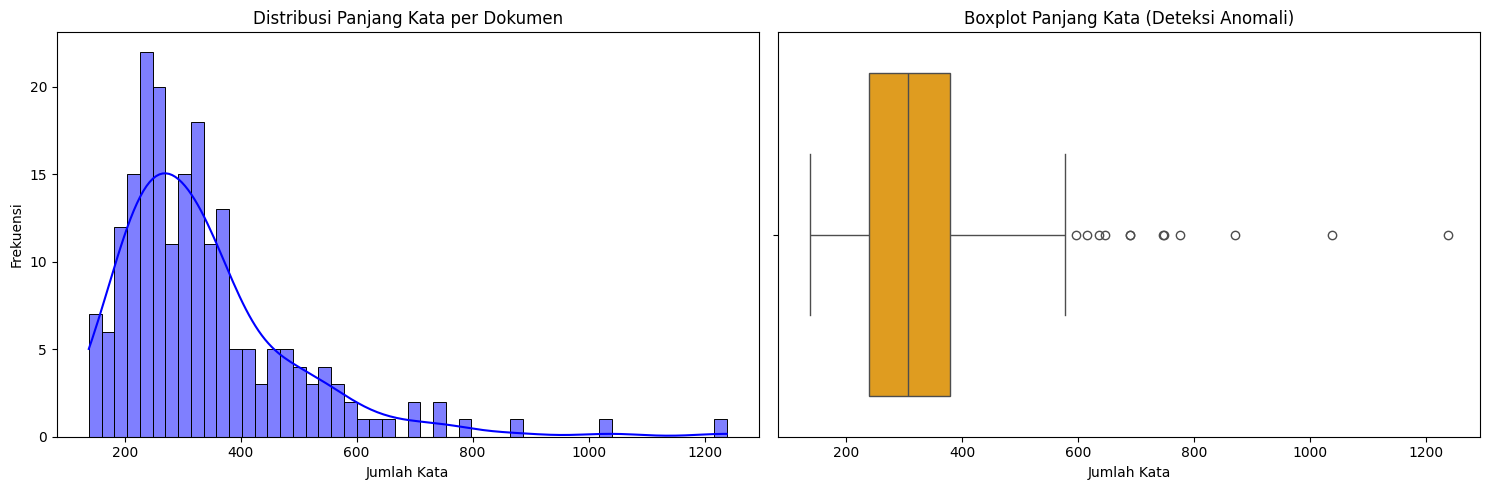

=== Statistik Deskriptif Panjang Kata ===


count     200.000000
mean      337.535000
std       155.955601
min       138.000000
25%       239.000000
50%       306.000000
75%       378.500000
max      1238.000000
Name: jumlah_kata, dtype: float64

In [24]:
print("Menganalisis panjang kata untuk mendeteksi anomali...")
visualisasi_panjang_kata(df_all, 'teks')

Membuat WordCloud...


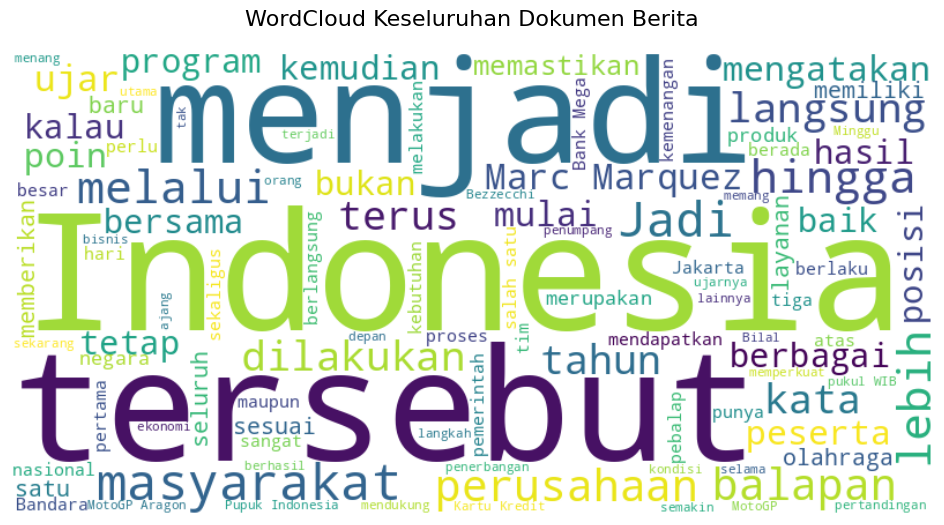

In [25]:
print("Membuat WordCloud...")
visualisasi_wordcloud(df_all['teks'])

In [26]:
hasil = cari_kata("saham")
display(hasil.head())

Ditemukan 8 dokumen yang mengandung kata 'saham'.


,kategori,teks
106,finance,Lembaga Penjamin Simpanan (LPS) memiliki dua f...
109,finance,Direktur Jenderal Stabilitas dan Pengembangan ...
146,finance,"Founder & Chairman CT Corp, Chairul Tanjung me..."
148,finance,Pasangan selebriti yang juga pendiri RANS Ente...
193,finance,PT Bank Tabungan Negara (Persero) Tbk (BTN) me...


### Eksplorasi Teks dan Interpretasi Output

`str.len()` pada pemeriksaan awal menghitung jumlah karakter, termasuk spasi dan tanda baca. Fungsi `visualisasi_panjang_kata` menghitung token dengan `split()`, lalu menyajikan histogram, boxplot, dan statistik deskriptif untuk melihat sebaran serta dokumen yang panjangnya menyimpang. Keduanya mengukur hal berbeda.

WordCloud merangkum kata yang paling sering muncul pada gabungan teks; ukuran kata mencerminkan frekuensi, bukan tingkat kepentingan atau sentimen. Fungsi `cari_kata` mencari substring tanpa membedakan huruf besar-kecil dan menampilkan kategori serta cuplikan teks yang cocok. Eksplorasi ini membantu memahami korpus sebelum menentukan preprocessing, tetapi bukan pengganti evaluasi model.

## **Data Preprocessing**

Teks dibersihkan dan diubah menjadi list token sebelum dilatih dengan Word2Vec. Case folding menyeragamkan huruf, pembersihan tanda baca mengurangi variasi token, tokenisasi memisahkan teks menjadi kata, dan opsi angka, stopword, serta stemming mengatur informasi mana yang dipertahankan.

Fungsi preprocessing yang sama digunakan dalam lima konfigurasi. Perbedaan konfigurasi memungkinkan kita mengamati pengaruh keputusan preprocessing terhadap embedding dan hasil klasifikasi:

| Skenario | Angka | Stopword | Stemming |
|---|---|---|---|
| 1 | Dihapus | Dihapus | Aktif |
| 2 | Dipertahankan | Dihapus | Aktif |
| 3 | Dihapus | Dipertahankan | Aktif |
| 4 | Dihapus | Dihapus | Tidak aktif |
| 5 | Dipertahankan | Dipertahankan | Aktif |

Tabel ini mengikuti argumen aktual pada pemanggilan `preprocess_modular`. Karena perubahan dilakukan per konfigurasi, perbandingan hasil perlu mempertimbangkan bahwa Skenario 3 menguji stopword, Skenario 4 menguji stemming, dan Skenario 5 mempertahankan angka sekaligus stopword.

In [27]:
def preprocess_modular(teks, hapus_angka=True, hapus_stopword=True, pakai_stemming=True):
    # 1. Case Folding & Hapus Tanda Baca
    teks = str(teks).lower()
    teks = re.sub(r'[^\w\s]', ' ', teks)
    
    # 2. Opsional: Hapus Angka
    if hapus_angka:
        teks = re.sub(r'\d+', '', teks)
        
    # 3. Tokenisasi
    tokens = teks.split()
    
    # 4. Opsional: Hapus Stopword
    if hapus_stopword:
        tokens = [w for w in tokens if w not in daftar_stopword]
        
    # 5. Opsional: Stemming
    if pakai_stemming:
        teks_gabung = " ".join(tokens)
        teks_stem = stemmer.stem(teks_gabung)
        tokens = teks_stem.split()
        
    # Return list of tokens (Format ideal untuk Gensim Word2Vec)
    return tokens

In [28]:
def latih_skipgram(list_of_tokens, ukuran_vektor=50, ukuran_window=2):
    """Melatih model Word2Vec Skip-gram dari kolom token dataframe."""
    model = Word2Vec(
        sentences=list_of_tokens,
        vector_size=ukuran_vektor,
        window=ukuran_window,
        sg=1,          # sg=1 mengaktifkan Skip-gram
        min_count=1,   # Pastikan semua kata masuk vocabulary
        workers=4,     # Mempercepat komputasi
        seed=42
    )
    return model

def get_vektor_rata_rata(tokens, model):
    """Merata-ratakan vektor setiap kata menjadi 1 vektor dokumen untuk klasifikasi ML."""
    vektor_kata = [model.wv[kata] for kata in tokens if kata in model.wv]
    
    if not vektor_kata:
        # Jika dokumen kosong (semua kata terhapus stopword), kembalikan array 0
        return np.zeros(model.vector_size)
        
    return np.mean(vektor_kata, axis=0)

In [29]:
def tuning_w2v_naive_bayes(tokens_series, target_series, list_vektor, list_window, list_smoothing):
    hasil = []
    # Matatikan log gensim agar output loop tidak terlalu penuh
    logging.getLogger().setLevel(logging.WARNING) 
    
    for v in list_vektor:
        for w in list_window:
            print(f"Melatih Skip-gram (Vektor={v}, Window={w})...")
            # 1. Latih Word2Vec
            model_w2v = latih_skipgram(tokens_series, ukuran_vektor=v, ukuran_window=w)
            
            # 2. Mean Pooling
            fitur_X = tokens_series.apply(lambda x: get_vektor_rata_rata(x, model_w2v))
            X_df = pd.DataFrame(fitur_X.tolist())
            
            # 3. Split Data
            X_train, X_test, y_train, y_test = train_test_split(
                X_df, target_series, test_size=0.2, random_state=42, stratify=target_series
            )
            
            # 4. Tuning Naive Bayes
            for smooth in list_smoothing:
                nb = GaussianNB(var_smoothing=smooth)
                nb.fit(X_train, y_train)
                akurasi = accuracy_score(y_test, nb.predict(X_test))
                
                hasil.append({
                    'Vector_Size': v, 'Window': w, 
                    'Var_Smoothing': smooth, 'Akurasi': akurasi
                })
                
    return pd.DataFrame(hasil).sort_values(by='Akurasi', ascending=False).reset_index(drop=True)

### Melatih Embedding dan Membentuk Fitur Dokumen

`latih_skipgram` melatih Word2Vec dari list token. Arsitektur dipilih dengan `sg=1`; `vector_size` menentukan dimensi vektor kata, sedangkan `window` menentukan jangkauan konteks. Fungsi menerima nilai dimensi dan window sebagai argumen, sehingga tuning dapat mencoba konfigurasi berbeda. `min_count=1` mempertahankan kata langka, tetapi kata dengan sedikit konteks mungkin memiliki vektor yang kurang stabil.

Model memberikan satu vektor untuk setiap kata. Agar dapat digunakan classifier, `get_vektor_rata_rata` merangkum vektor kata dalam artikel menjadi satu vektor dokumen:

$$\mathbf{d} = \frac{1}{m} \sum_{i=1}^{m} \mathbf{v}_{w_i}$$

`m` adalah jumlah token yang ada dalam vocabulary model. Hasilnya memiliki jumlah fitur tetap yang sama dengan `vector_size`. Dokumen tanpa token yang dikenal mendapat vektor nol. Mean pooling praktis, tetapi menghilangkan urutan kata dan memberi kontribusi rata-rata yang sama pada token-token dokumen.

### Hyperparameter Tuning Word2Vec dan Naive Bayes

Fungsi `tuning_w2v_naive_bayes` menguji kombinasi tiga parameter:

- `vector_size`: 50, 75, atau 100 dimensi;
- `window`: 3, 5, atau 7 token konteks;
- `var_smoothing` Gaussian Naive Bayes: $10^{-9}$, $10^{-5}$, atau $10^{-1}$.

Tiga pilihan untuk setiap parameter menghasilkan 27 kombinasi per skenario. Untuk setiap kombinasi `vector_size` dan `window`, fungsi melatih Word2Vec, melakukan mean pooling untuk membentuk fitur artikel, membagi fitur dan label dengan `test_size=0.2` serta `stratify`, lalu mencoba ketiga nilai `var_smoothing`. Akurasi tiap percobaan disimpan dan tabel hasil diurutkan dari akurasi terbesar.

Tabel **TOP 5** menunjukkan lima kombinasi dengan akurasi tertinggi pada eksperimen tersebut. Heatmap merangkum akurasi menurut `vector_size` dan `window` setelah hasil difilter ke satu nilai `var_smoothing` terbaik. Ini membantu membandingkan pola parameter, tetapi bukan bukti bahwa hasil akan sama pada data baru.

In [30]:
daftar_stopword = set(StopWordRemoverFactory().get_stop_words())
stemmer = StemmerFactory().create_stemmer()

tqdm.pandas()

### Skenario 1: Menghapus Angka

Daftar stopword dibuat sebagai `set` agar pemeriksaan keanggotaan token efisien, sedangkan stemmer Sastrawi disiapkan satu kali untuk digunakan berulang kali. `tqdm.pandas()` mengaktifkan progress bar pada pemrosesan kolom.

Pada skenario 1, preprocessing dijalankan dengan `hapus_angka=True`, `hapus_stopword=True`, dan `pakai_stemming=True`. Dengan demikian angka, stopword, dan imbuhan diproses sesuai konfigurasi tersebut. Pilihan ini berguna ketika angka tidak dianggap sebagai pembeda kategori, tetapi dapat menghilangkan informasi penting seperti tahun, skor, atau nomor pertandingan.

In [31]:
# Preprocessing Penuh (Hapus Angka, Stopword, Stemming)
print("1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...")
df_all['token_skenario_1'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=True, hapus_stopword=True, pakai_stemming=True)
)

1. Memulai Preprocessing Skenario 1 (Ini akan memakan waktu karena Stemming)...


100%|██████████| 200/200 [09:32<00:00,  2.86s/it]


In [32]:
print("Memulai Hyperparameter Tuning Skenario 1...")

hasil_tuning_skenario_1 = tuning_w2v_naive_bayes(
    tokens_series=df_all['token_skenario_1'], 
    target_series=df_all['kategori'], 
    list_vektor=[50, 75, 100],               # Uji 2 parameter vector size
    list_window=[3, 5, 7],                  # Uji 2 parameter window
    list_smoothing=[1e-9, 1e-5, 1e-1]    # Uji 3 parameter Naive Bayes
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")
display(hasil_tuning_skenario_1.head())

Memulai Hyperparameter Tuning Skenario 1...
Melatih Skip-gram (Vektor=50, Window=3)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=100, Window=7)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,3,1.000000e-09,0.775
1,50,3,1.000000e-05,0.775
2,50,3,1.000000e-01,0.775
3,50,5,1.000000e-01,0.775
4,75,3,1.000000e-05,0.775


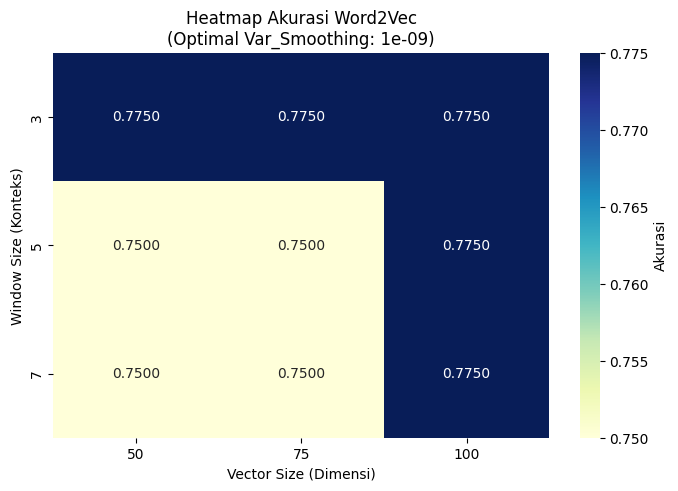

In [33]:
best_smooth = hasil_tuning_skenario_1['Var_Smoothing'].iloc[0]

# Memfilter data hanya untuk var_smoothing terbaik agar bisa dibuat heatmap 2D
df_heatmap = hasil_tuning_skenario_1[hasil_tuning_skenario_1['Var_Smoothing'] == best_smooth]

# Membuat pivot table: Baris = Window, Kolom = Vector Size, Nilai = Akurasi
pivot_table = df_heatmap.pivot(index='Window', columns='Vector_Size', values='Akurasi')

# Menggambar Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Akurasi'})
plt.title(f'Heatmap Akurasi Word2Vec\n(Optimal Var_Smoothing: {best_smooth})')
plt.xlabel('Vector Size (Dimensi)')
plt.ylabel('Window Size (Konteks)')
plt.show()

### Membaca Hasil Tuning dan Heatmap

Tabel yang ditampilkan setelah tuning berisi lima kombinasi dengan akurasi tertinggi untuk Skenario 1. Heatmap berikut memvisualisasikan akurasi pada setiap pasangan `Vector_Size` dan `Window`, dengan `Var_Smoothing` terbaik dari tabel hasil tuning ditahan tetap. Warna dan angka di dalam sel membantu melihat pola pada grid parameter; gunakan nilai aktual hasil eksekusi saat melaporkan konfigurasi terbaik.

### Skenario 2: Angka Dipertahankan

Skenario 2 menggunakan angka, menghapus stopword, dan melakukan stemming. Parameter Word2Vec serta Naive Bayes dituning tersendiri untuk token skenario ini.

In [34]:
# Skenario 2: Pertahankan Angka, Hapus Stopword, Stemming
print("2. Memulai Preprocessing Skenario 2...")
df_all['token_skenario_2'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=False, hapus_stopword=True, pakai_stemming=True)
)

2. Memulai Preprocessing Skenario 2...


100%|██████████| 200/200 [00:30<00:00,  6.56it/s]


In [35]:
print("Memulai Hyperparameter Tuning Skenario 2...")

hasil_tuning_skenario_2 = tuning_w2v_naive_bayes(
    tokens_series=df_all['token_skenario_2'], 
    target_series=df_all['kategori'], 
    list_vektor=[50, 75, 100],               # Uji 2 parameter vector size
    list_window=[3, 5, 7],                  # Uji 2 parameter window
    list_smoothing=[1e-9, 1e-5, 1e-1]    # Uji 3 parameter Naive Bayes
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")
display(hasil_tuning_skenario_2.head())

Memulai Hyperparameter Tuning Skenario 2...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=50, Window=7)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,5,1.000000e-09,0.850
1,50,5,1.000000e-05,0.850
2,50,7,1.000000e-09,0.825
3,50,7,1.000000e-05,0.825
4,50,3,1.000000e-01,0.800


### Skenario 3: Angka Dihapus, Stopword Dipertahankan

Pada skenario ini `hapus_angka=True`, `hapus_stopword=False`, dan `pakai_stemming=True`. Dibandingkan Skenario 1, angka tetap dihapus dan stemming tetap dilakukan, tetapi stopword dipertahankan. Hasil tuning skenario ini menguji apakah mempertahankan kata umum memberi pengaruh pada fitur embedding dan klasifikasi.

In [36]:
# Skenario 3: Pertahankan Angka, Hapus Stopword, Stemming
print("3. Memulai Preprocessing Skenario 3...")
df_all['token_skenario_3'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=True, hapus_stopword=False, pakai_stemming=True)
)

3. Memulai Preprocessing Skenario 3...


100%|██████████| 200/200 [00:00<00:00, 204.53it/s]


In [37]:
print("Memulai Hyperparameter Tuning Skenario 3...")

hasil_tuning_skenario_3 = tuning_w2v_naive_bayes(
    tokens_series=df_all['token_skenario_3'], 
    target_series=df_all['kategori'], 
    list_vektor=[50, 75, 100],               # Uji 2 parameter vector size
    list_window=[3, 5, 7],                  # Uji 2 parameter window
    list_smoothing=[1e-9, 1e-5, 1e-1]    # Uji 3 parameter Naive Bayes
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")
display(hasil_tuning_skenario_3.head())

Memulai Hyperparameter Tuning Skenario 3...
Melatih Skip-gram (Vektor=50, Window=3)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=50, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=75, Window=7)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,5,1.000000e-09,0.775
1,50,5,1.000000e-05,0.775
2,100,3,1.000000e-01,0.775
3,50,3,1.000000e-01,0.750
4,50,3,1.000000e-05,0.750


### Skenario 4: Angka dan Stopword Dihapus, Tanpa Stemming

Kode menggunakan `hapus_angka=True`, `hapus_stopword=True`, dan `pakai_stemming=False`. Dengan demikian angka serta stopword dihapus, tetapi kata tidak dikembalikan ke bentuk dasar. Parameter model lalu dituning untuk konfigurasi token ini.

In [38]:
# Skenario 4: Pertahankan Angka, Hapus Stopword, Stemming
print("4. Memulai Preprocessing Skenario 4...")
df_all['token_skenario_4'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=True, hapus_stopword=True, pakai_stemming=False)
)

4. Memulai Preprocessing Skenario 4...


100%|██████████| 200/200 [00:00<00:00, 2302.90it/s]


In [39]:
print("Memulai Hyperparameter Tuning Skenario 4...")

hasil_tuning_skenario_4 = tuning_w2v_naive_bayes(
    tokens_series=df_all['token_skenario_4'], 
    target_series=df_all['kategori'], 
    list_vektor=[50, 75, 100],               # Uji 2 parameter vector size
    list_window=[3, 5, 7],                  # Uji 2 parameter window
    list_smoothing=[1e-9, 1e-5, 1e-1]    # Uji 3 parameter Naive Bayes
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")
display(hasil_tuning_skenario_4.head())

Memulai Hyperparameter Tuning Skenario 4...
Melatih Skip-gram (Vektor=50, Window=3)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=75, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,75,5,1.000000e-09,0.900
1,75,5,1.000000e-05,0.900
2,75,5,1.000000e-01,0.825
3,50,7,1.000000e-05,0.800
4,75,3,1.000000e-09,0.800


### Skenario 5: Angka dan Stopword Dipertahankan

Pada konfigurasi kelima, angka serta stopword dipertahankan dan stemming tetap aktif (`hapus_angka=False`, `hapus_stopword=False`, `pakai_stemming=True`). Model kemudian dituning dengan grid parameter yang sama untuk memudahkan perbandingan hasil.

In [40]:
# Skenario 5: Pertahankan Angka, Hapus Stopword, Stemming
print("5. Memulai Preprocessing Skenario 5...")
df_all['token_skenario_5'] = df_all['teks'].progress_apply(
    lambda x: preprocess_modular(x, hapus_angka=False, hapus_stopword=False, pakai_stemming=True)
)

5. Memulai Preprocessing Skenario 5...


100%|██████████| 200/200 [00:00<00:00, 1255.27it/s]


In [41]:
print("Memulai Hyperparameter Tuning Skenario 5...")

hasil_tuning_skenario_5 = tuning_w2v_naive_bayes(
    tokens_series=df_all['token_skenario_5'], 
    target_series=df_all['kategori'], 
    list_vektor=[50, 75, 100],               # Uji 2 parameter vector size
    list_window=[3, 5, 7],                  # Uji 2 parameter window
    list_smoothing=[1e-9, 1e-5, 1e-1]    # Uji 3 parameter Naive Bayes
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")
display(hasil_tuning_skenario_5.head())

Memulai Hyperparameter Tuning Skenario 5...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,3,1.000000e-01,0.775
1,75,3,1.000000e-05,0.775
2,75,3,1.000000e-09,0.775
3,50,3,1.000000e-05,0.750
4,50,3,1.000000e-09,0.750


## **Modeling dan Evaluasi**

Fitur dokumen dari Word2Vec digunakan untuk melatih Gaussian Naive Bayes dalam memprediksi label kategori. Pada pembagian data, `test_size=0.2` menyisihkan 20% dokumen untuk pengujian, `random_state=42` membuat pembagian dapat diulang, dan `stratify` menjaga proporsi kelas pada data latih dan uji.

**Catatan evaluasi:** pada alur saat ini, Word2Vec dilatih menggunakan seluruh dokumen sebelum `train_test_split`. Walaupun model embedding tidak menggunakan label kategori, teks yang nantinya menjadi data uji sudah ikut memengaruhi vocabulary dan vektor. Karena itu, pengukuran ini bukan evaluasi holdout yang sepenuhnya independen. Untuk evaluasi yang lebih ketat, pembagian dokumen dilakukan lebih dahulu, Word2Vec dilatih hanya pada teks latih, lalu vektor dokumen uji dibentuk menggunakan embedding hasil data latih. Ini adalah rekomendasi metodologis; kode notebook tidak diubah.

### Skenario 1: Menghapus Angka

Model ini memakai fitur dokumen dari preprocessing skenario 1, yaitu angka dihapus, stopword dihilangkan, dan kata di-stemming.

**Pembagian data Skenario 1.** Data fitur `X` dan label `y` dibagi dengan urutan yang sama. Proporsi kelas dijaga melalui `stratify`; hasil prediksi pada bagian test mengukur performa pada dokumen yang tidak digunakan untuk melatih classifier.

In [42]:
print("=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===")
best_v1 = int(hasil_tuning_skenario_1['Vector_Size'].iloc[0])
best_w1 = int(hasil_tuning_skenario_1['Window'].iloc[0])
best_s1 = float(hasil_tuning_skenario_1['Var_Smoothing'].iloc[0])

print(f"Menggunakan Parameter -> Vector: {best_v1}, Window: {best_w1}, Smoothing: {best_s1}\n")

=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===
Menggunakan Parameter -> Vector: 50, Window: 3, Smoothing: 1e-09



In [43]:
# 1. Ekstraksi Fitur Ulang dengan Parameter Terbaik
model_w2v_final_s1 = latih_skipgram(df_all['token_skenario_1'], ukuran_vektor=best_v1, ukuran_window=best_w1)
fitur_X_final_s1 = df_all['token_skenario_1'].apply(lambda x: get_vektor_rata_rata(x, model_w2v_final_s1))
X_df_final_s1 = pd.DataFrame(fitur_X_final_s1.tolist())
y_df_final_s1 = df_all['kategori']

In [44]:
# 2. Split Data Skenario 1
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_df_final_s1, y_df_final_s1, test_size=0.2, random_state=42, stratify=y_df_final_s1
)

**Gaussian Naive Bayes Skenario 1.** Model dilatih menggunakan fitur dokumen berdimensi `best_v1`, yaitu nilai `Vector_Size` terpilih dari tabel tuning, dan label kategori data training. `fit` mempelajari pola kelas, sedangkan `predict` memperkirakan label untuk data test. Gaussian Naive Bayes mengasumsikan distribusi Gaussian tiap fitur dalam kelas dan independensi bersyarat antarf fitur.

In [46]:
# 3. Latih Model Naive Bayes Final
nb_final_s1 = GaussianNB(var_smoothing=best_s1)
nb_final_s1.fit(X_train_s1, y_train_s1)
y_pred_final_s1 = nb_final_s1.predict(X_test_s1)

**Membaca evaluasi Skenario 1.** Accuracy adalah proporsi seluruh prediksi yang benar. Precision mengukur ketepatan prediksi suatu kelas, recall mengukur berapa banyak anggota kelas yang berhasil ditemukan, dan F1 merupakan keseimbangan precision-recall. Laporan klasifikasi menampilkan nilai tersebut untuk tiap kategori. Pada confusion matrix, baris menunjukkan label sebenarnya dan kolom menunjukkan label prediksi; nilai di luar diagonal adalah kesalahan klasifikasi. Gunakan angka keluaran aktual untuk menyimpulkan kelas mana yang lebih mudah atau sulit dikenali.

=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===
Akurasi Model : 82.50%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

     finance       0.74      1.00      0.85        20
       sport       1.00      0.65      0.79        20

    accuracy                           0.82        40
   macro avg       0.87      0.82      0.82        40
weighted avg       0.87      0.82      0.82        40



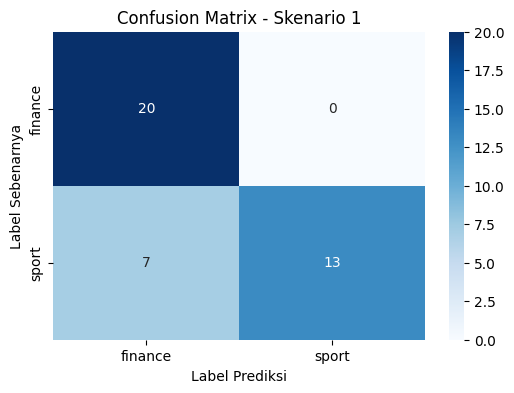

In [47]:
print("=== HASIL EVALUASI NAIVE BAYES (SKENARIO 1) ===")
print(f"Akurasi Model : {accuracy_score(y_test_s1, y_pred_final_s1) * 100:.2f}%\n")
print("Laporan Klasifikasi Detail:")
print(classification_report(y_test_s1, y_pred_final_s1))

# 6. Visualisasi Confusion Matrix (Opsional, sangat bagus untuk laporan)
cm = confusion_matrix(y_test_s1, y_pred_final_s1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_final_s1.classes_, 
            yticklabels=nb_final_s1.classes_)
plt.title('Confusion Matrix - Skenario 1')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

In [ ]:
# Pilih indeks berita yang ingin dilihat (misal: dokumen ke-101 / indeks 101)
idx = 101

print(f"=== INFORMASI DOKUMEN KE-{idx} (SKENARIO 1) ===")
# Memanggil label dari variabel final Skenario 1
print(f"Kategori : {y_df_final_s1.iloc[idx]}")

# Memanggil jumlah dan sampel token dari kolom token Skenario 1
print(f"Jumlah Token : {len(df_all['token_skenario_1'].iloc[idx])} kata")
print(f"Sampel Token : {df_all['token_skenario_1'].iloc[idx][:10]}...\n")

# Mengambil baris vektor dari DataFrame X final Skenario 1
vektor_dokumen = X_df_final_s1.iloc[idx].values

print(f"Bentuk Vektor (Shape) : {vektor_dokumen.shape}")
print(f"Representasi Vektor ({len(vektor_dokumen)} Dimensi):")
print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 1) ===
Kategori : finance
Jumlah Token : 234 kata
Sampel Token : ['ketua', 'badan', 'lindung', 'konsumen', 'nasional', 'bpkn', 'mufti', 'mubarok', 'minta', 'perintah']...

Bentuk Vektor (Shape) : (50,)
Representasi Vektor (50 Dimensi):
[ 0.04020155 -0.51387805  0.31336153 -0.02807101  0.1231763   0.28466722
 -0.05033119  0.05695695 -0.1491481   0.2012972  -0.15744567  0.13335766
  0.03634099  0.28720224  0.26883167 -0.22698767  0.02468414 -0.16709505
 -0.32321995 -0.05137025 -0.10791039  0.22348472 -0.21372841  0.1571014
 -0.02000372  0.0172297  -0.15544915  0.35404474 -0.06798056 -0.36390188
 -0.10664698 -0.03397197 -0.10763393  0.03295362 -0.23513354  0.14435919
  0.08454856 -0.74366075  0.17399001  0.06191656 -0.17489219  0.28285155
  0.23698062 -0.2892331   0.32687923  0.17542227  0.18053196  0.26430404
  0.10973699 -0.26484337]


### Skenario 2: Angka Dipertahankan, Stopword Dihapus, Stemming Aktif

Skenario 2 mempertahankan angka, tetapi tetap menghapus stopword dan melakukan stemming. Setelah tuning tersendiri, notebook memilih parameter terbaik skenario ini, membentuk ulang embedding serta fitur dokumen, lalu mengevaluasi classifier. Bandingkan dengan skenario lain menggunakan metrik aktual dan perhatikan bahwa hasilnya menunjukkan eksperimen pada dataset ini saja.

**Pembagian data Skenario 2.** Fitur dokumen final dan label dibagi dengan `stratify=y_df_final_s2`, sehingga proporsi kelas dijaga. Bagian test digunakan untuk mengevaluasi classifier, tetapi embedding sebelumnya telah dilatih dengan teks seluruh korpus.

In [ ]:
print("=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===")
best_v2 = int(hasil_tuning_skenario_2['Vector_Size'].iloc[0])
best_w2 = int(hasil_tuning_skenario_2['Window'].iloc[0])
best_s2 = float(hasil_tuning_skenario_2['Var_Smoothing'].iloc[0])

print(f"Menggunakan Parameter -> Vector: {best_v2}, Window: {best_w2}, Smoothing: {best_s2}\n")

=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===
Menggunakan Parameter -> Vector: 50, Window: 7, Smoothing: 1e-09



In [ ]:
# 1. Ekstraksi Fitur Ulang dengan Parameter Terbaik
model_w2v_final_s2 = latih_skipgram(df_all['token_skenario_2'], ukuran_vektor=best_v2, ukuran_window=best_w2)
fitur_X_final_s2 = df_all['token_skenario_2'].apply(lambda x: get_vektor_rata_rata(x, model_w2v_final_s2))
X_df_final_s2 = pd.DataFrame(fitur_X_final_s2.tolist())
y_df_final_s2 = df_all['kategori']

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [ ]:
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_df_final_s2, y_df_final_s2, test_size=0.2, random_state=42, stratify=y_df_final_s2
)

**Gaussian Naive Bayes Skenario 2.** Model final menggunakan `var_smoothing` terbaik dari tuning Skenario 2 dan dilatih dengan fitur hasil mean pooling serta label kategori pada bagian training. `predict` mengeluarkan prediksi label bagi data test. Dimensi fitur mengikuti `best_v2`, bukan selalu 50.

In [ ]:
# 3. Latih Model Final Skenario 2
nb_final_s2 = GaussianNB(var_smoothing=best_s2)
nb_final_s2.fit(X_train_s2, y_train_s2)
y_pred_s2 = nb_final_s2.predict(X_test_s2)

**Membaca evaluasi Skenario 2.** Perhatikan accuracy bersama precision, recall, F1, dan confusion matrix. Bandingkan metrik dengan skenario lain, tetapi jangan menganggap selisih kecil sebagai bukti umum bahwa mempertahankan angka selalu membantu atau merugikan. Tuning dan pembentukan embedding menggunakan korpus yang sama, sehingga interpretasi performa perlu mempertimbangkan batas evaluasi yang dijelaskan sebelumnya.

LAPORAN KLASIFIKASI SKENARIO 2:
Akurasi Model : 75.00%

              precision    recall  f1-score   support

     finance       0.68      0.95      0.79        20
       sport       0.92      0.55      0.69        20

    accuracy                           0.75        40
   macro avg       0.80      0.75      0.74        40
weighted avg       0.80      0.75      0.74        40



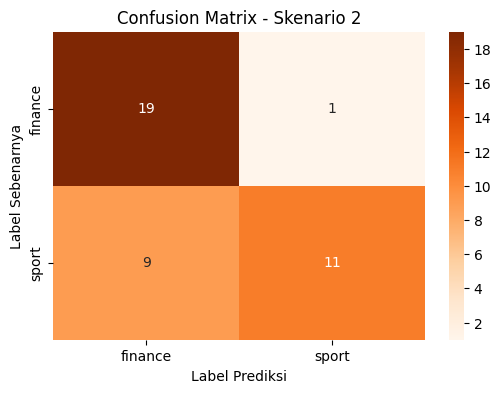

In [ ]:
print("LAPORAN KLASIFIKASI SKENARIO 2:")
print(f"Akurasi Model : {accuracy_score(y_test_s2, y_pred_s2) * 100:.2f}%\n")
print(classification_report(y_test_s2, y_pred_s2))

cm2 = confusion_matrix(y_test_s2, y_pred_s2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nb_final_s2.classes_,
            yticklabels=nb_final_s2.classes_)
plt.title('Confusion Matrix - Skenario 2')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

In [ ]:
# Pilih indeks berita yang ingin dilihat (misal: dokumen ke-101 / indeks 101)
idx = 101

print(f"=== INFORMASI DOKUMEN KE-{idx} (SKENARIO 2) ===")
# Memanggil label dari variabel final Skenario 2
print(f"Kategori : {y_df_final_s2.iloc[idx]}")

# Memanggil jumlah dan sampel token dari kolom token Skenario 2
print(f"Jumlah Token : {len(df_all['token_skenario_2'].iloc[idx])} kata")
print(f"Sampel Token : {df_all['token_skenario_2'].iloc[idx][:10]}...\n")

# Mengambil baris vektor dari DataFrame X final Skenario 2
vektor_dokumen = X_df_final_s2.iloc[idx].values

print(f"Bentuk Vektor (Shape) : {vektor_dokumen.shape}")
print(f"Representasi Vektor ({len(vektor_dokumen)} Dimensi):")
print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 2) ===
Kategori : finance
Jumlah Token : 238 kata
Sampel Token : ['ketua', 'badan', 'lindung', 'konsumen', 'nasional', 'bpkn', 'mufti', 'mubarok', 'minta', 'perintah']...

Bentuk Vektor (Shape) : (50,)
Representasi Vektor (50 Dimensi):
[ 0.25638694 -0.47296408  0.35532057 -0.15059166 -0.17767364  0.3547623
  0.11207014  0.33601886 -0.18471555  0.14499067 -0.48463288  0.14253855
 -0.50174856  0.21966997  0.2990941  -0.21833315  0.10215095 -0.16404368
 -0.13071339  0.16419818 -0.22361234  0.1705404   0.07208886 -0.00422811
  0.30934685 -0.03511598  0.13024667  0.17171313 -0.10916322 -0.16449513
  0.24417087 -0.22414002  0.21479873 -0.00149418 -0.4882957   0.02251448
  0.1309432  -0.43939045  0.0084844   0.2534285  -0.37492877  0.0379643
  0.30465695 -0.04828845  0.4914939  -0.25258893  0.15563808  0.16419828
 -0.05041227 -0.35712737]


### Model Final Skenario 3

Nilai `best_v3`, `best_w3`, dan `best_s3` diambil dari kombinasi dengan akurasi tuning tertinggi pada Skenario 3. Kombinasi ini digunakan untuk melatih ulang embedding dan Gaussian Naive Bayes final, lalu hasil prediksi dievaluasi pada pembagian data stratified.

In [ ]:
print("=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===")
best_v3 = int(hasil_tuning_skenario_3['Vector_Size'].iloc[0])
best_w3 = int(hasil_tuning_skenario_3['Window'].iloc[0])
best_s3 = float(hasil_tuning_skenario_3['Var_Smoothing'].iloc[0])

print(f"Menggunakan Parameter -> Vector: {best_v3}, Window: {best_w3}, Smoothing: {best_s3}\n")

=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===
Menggunakan Parameter -> Vector: 100, Window: 3, Smoothing: 0.1



In [ ]:
# 1. Ekstraksi Fitur Ulang dengan Parameter Terbaik
model_w2v_final_s3 = latih_skipgram(df_all['token_skenario_3'], ukuran_vektor=best_v3, ukuran_window=best_w3)
fitur_X_final_s3 = df_all['token_skenario_3'].apply(lambda x: get_vektor_rata_rata(x, model_w2v_final_s3))
X_df_final_s3 = pd.DataFrame(fitur_X_final_s3.tolist())
y_df_final_s3 = df_all['kategori']

In [ ]:
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_df_final_s3, y_df_final_s3, test_size=0.2, random_state=42, stratify=y_df_final_s3
)

In [ ]:
# 3. Latih Model Final Skenario 3
nb_final_s3 = GaussianNB(var_smoothing=best_s3)
nb_final_s3.fit(X_train_s3, y_train_s3)
y_pred_s3 = nb_final_s3.predict(X_test_s3)

LAPORAN KLASIFIKASI SKENARIO 3:
Akurasi Model : 77.50%

              precision    recall  f1-score   support

     finance       0.69      1.00      0.82        20
       sport       1.00      0.55      0.71        20

    accuracy                           0.78        40
   macro avg       0.84      0.78      0.76        40
weighted avg       0.84      0.78      0.76        40



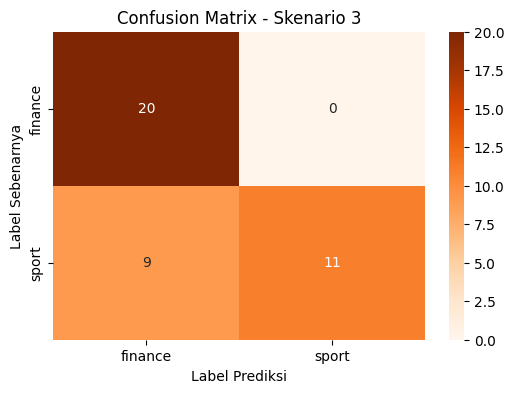

In [ ]:
print("LAPORAN KLASIFIKASI SKENARIO 3:")
print(f"Akurasi Model : {accuracy_score(y_test_s3, y_pred_s3) * 100:.2f}%\n")
print(classification_report(y_test_s3, y_pred_s3))

cm3 = confusion_matrix(y_test_s3, y_pred_s3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', # Menggunakan warna Oranges agar beda dengan Skenario 1 (Blues)
            xticklabels=nb_final_s3.classes_,
            yticklabels=nb_final_s3.classes_)
plt.title('Confusion Matrix - Skenario 3')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

In [ ]:
# Pilih indeks berita yang ingin dilihat (misal: dokumen ke-101 / indeks 101)
idx = 101

print(f"=== INFORMASI DOKUMEN KE-{idx} (SKENARIO 3) ===")
# Memanggil label dari variabel final Skenario 3
print(f"Kategori : {y_df_final_s3.iloc[idx]}")

# Memanggil jumlah dan sampel token dari kolom token Skenario 3
print(f"Jumlah Token : {len(df_all['token_skenario_3'].iloc[idx])} kata")
print(f"Sampel Token : {df_all['token_skenario_3'].iloc[idx][:10]}...\n")

# Mengambil baris vektor dari DataFrame X final Skenario 3
vektor_dokumen = X_df_final_s3.iloc[idx].values

print(f"Bentuk Vektor (Shape) : {vektor_dokumen.shape}")
print(f"Representasi Vektor ({len(vektor_dokumen)} Dimensi):")
print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 3) ===
Kategori : finance
Jumlah Token : 328 kata
Sampel Token : ['ketua', 'badan', 'lindung', 'konsumen', 'nasional', 'bpkn', 'mufti', 'mubarok', 'minta', 'perintah']...

Bentuk Vektor (Shape) : (100,)
Representasi Vektor (100 Dimensi):
[ 0.11839116 -0.11424357 -0.06663416 -0.02160475 -0.30776632  0.09191155
  0.04735298  0.30866754 -0.12030139  0.09773953 -0.16438326  0.23141679
 -0.00947482  0.19718215 -0.15003158 -0.0561731  -0.00788136 -0.17909108
 -0.23958504 -0.06084428  0.06978177  0.09099984 -0.159489    0.23901595
  0.18226887  0.02768661 -0.13514198  0.23841962 -0.10868514 -0.23630747
  0.09291255 -0.15984231  0.01348597  0.17201167  0.02120883 -0.15587004
  0.07790475 -0.29067943 -0.05250892  0.13560487 -0.14138909  0.04387802
  0.09611293 -0.32047105  0.08599382 -0.1667784   0.10034379  0.06775147
  0.3453558  -0.25404045 -0.01636706 -0.5541535   0.11656589 -0.16917615
  0.24234937  0.06557424 -0.22882512  0.05593178 -0.11646961  0.22

### Skenario 4: Stemming Tidak Digunakan

Skenario ini memakai `hapus_angka=True`, `hapus_stopword=True`, dan `pakai_stemming=False`. Angka serta stopword dihapus, tetapi kata berimbuhan tidak diubah ke bentuk dasar. Perbandingan dengan Skenario 1 terutama memperlihatkan pengaruh keputusan stemming dalam kombinasi preprocessing ini.

In [ ]:
print("=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===")
best_v4 = int(hasil_tuning_skenario_4['Vector_Size'].iloc[0])
best_w4 = int(hasil_tuning_skenario_4['Window'].iloc[0])
best_s4 = float(hasil_tuning_skenario_4['Var_Smoothing'].iloc[0])

print(f"Menggunakan Parameter -> Vector: {best_v4}, Window: {best_w4}, Smoothing: {best_s4}\n")

=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===
Menggunakan Parameter -> Vector: 75, Window: 3, Smoothing: 1e-09



In [ ]:
# 1. Ekstraksi Fitur Ulang dengan Parameter Terbaik
model_w2v_final_s4 = latih_skipgram(df_all['token_skenario_4'], ukuran_vektor=best_v4, ukuran_window=best_w4)
fitur_X_final_s4 = df_all['token_skenario_4'].apply(lambda x: get_vektor_rata_rata(x, model_w2v_final_s4))
X_df_final_s4 = pd.DataFrame(fitur_X_final_s4.tolist())
y_df_final_s4 = df_all['kategori']

In [ ]:
X_train_s4, X_test_s4, y_train_s4, y_test_s4 = train_test_split(
    X_df_final_s4, y_df_final_s4, test_size=0.2, random_state=42, stratify=y_df_final_s4
)

In [ ]:
# 3. Latih Model Final Skenario 4
nb_final_s4 = GaussianNB(var_smoothing=best_s4)
nb_final_s4.fit(X_train_s4, y_train_s4)
y_pred_s4 = nb_final_s4.predict(X_test_s4)

LAPORAN KLASIFIKASI SKENARIO 4:
Akurasi Model : 77.50%

              precision    recall  f1-score   support

     finance       0.69      1.00      0.82        20
       sport       1.00      0.55      0.71        20

    accuracy                           0.78        40
   macro avg       0.84      0.78      0.76        40
weighted avg       0.84      0.78      0.76        40



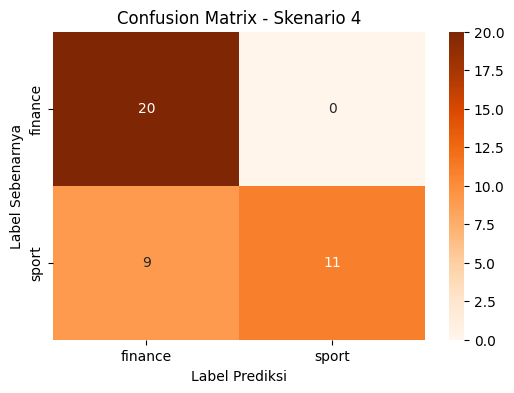

In [ ]:
print("LAPORAN KLASIFIKASI SKENARIO 4:")
print(f"Akurasi Model : {accuracy_score(y_test_s4, y_pred_s4) * 100:.2f}%\n")
print(classification_report(y_test_s4, y_pred_s4))

cm4 = confusion_matrix(y_test_s4, y_pred_s4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Oranges', # Menggunakan warna Oranges agar beda dengan Skenario 1 (Blues)
            xticklabels=nb_final_s4.classes_,
            yticklabels=nb_final_s4.classes_)
plt.title('Confusion Matrix - Skenario 4')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

In [ ]:
# Pilih indeks berita yang ingin dilihat (misal: dokumen ke-101 / indeks 101)
idx = 101

print(f"=== INFORMASI DOKUMEN KE-{idx} (SKENARIO 4) ===")
# Memanggil label dari variabel final Skenario 4
print(f"Kategori : {y_df_final_s4.iloc[idx]}")

# Memanggil jumlah dan sampel token dari kolom token Skenario 4
print(f"Jumlah Token : {len(df_all['token_skenario_4'].iloc[idx])} kata")
print(f"Sampel Token : {df_all['token_skenario_4'].iloc[idx][:10]}...\n")

# Mengambil baris vektor dari DataFrame X final Skenario 4
vektor_dokumen = X_df_final_s4.iloc[idx].values

print(f"Bentuk Vektor (Shape) : {vektor_dokumen.shape}")
print(f"Representasi Vektor ({len(vektor_dokumen)} Dimensi):")
print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 4) ===
Kategori : finance
Jumlah Token : 234 kata
Sampel Token : ['ketua', 'badan', 'perlindungan', 'konsumen', 'nasional', 'bpkn', 'mufti', 'mubarok', 'meminta', 'pemerintah']...

Bentuk Vektor (Shape) : (75,)
Representasi Vektor (75 Dimensi):
[ 0.08723245 -0.33887535  0.06446873 -0.13905995 -0.09863483  0.11029905
  0.06672682  0.11259311  0.03386452  0.10540023 -0.18483993 -0.17473578
  0.00062512 -0.14971344 -0.05481397 -0.12019449  0.15344676 -0.09915475
 -0.09864997 -0.08702063 -0.11410209  0.23068772  0.0841624   0.37135443
  0.16238198  0.17794943 -0.2544421  -0.29158822  0.12393116 -0.151109
  0.05648391 -0.22322226 -0.09579347  0.03190528 -0.02052233 -0.03620521
  0.250422   -0.40333247  0.15758862  0.18457012 -0.0499858   0.1317335
  0.1697811  -0.19474335 -0.01566458  0.175219    0.04078862  0.02149769
 -0.20156866  0.11957389 -0.29638937 -0.015892    0.06797341  0.08284707
  0.12264972  0.05415067 -0.11405018  0.23556142 -0.0994937  -

### Skenario 5: Angka dan Stopword Dipertahankan

Konfigurasi ini memakai `hapus_angka=False`, `hapus_stopword=False`, dan `pakai_stemming=True`. Angka dan stopword tetap menjadi token, sementara stemming dilakukan. Ini memungkinkan pengujian gabungan terhadap dua pilihan preprocessing tersebut; hasilnya tidak mengisolasi pengaruh satu pilihan saja dibandingkan Skenario 1.

In [ ]:
print("=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===")
best_v5 = int(hasil_tuning_skenario_5['Vector_Size'].iloc[0])
best_w5 = int(hasil_tuning_skenario_5['Window'].iloc[0])
best_s5 = float(hasil_tuning_skenario_5['Var_Smoothing'].iloc[0])

print(f"Menggunakan Parameter -> Vector: {best_v5}, Window: {best_w5}, Smoothing: {best_s5}\n")

=== PEMODELAN FINAL DENGAN PARAMETER TERBAIK ===
Menggunakan Parameter -> Vector: 75, Window: 3, Smoothing: 1e-09



In [ ]:
# 1. Ekstraksi Fitur Ulang dengan Parameter Terbaik
model_w2v_final_s5 = latih_skipgram(df_all['token_skenario_5'], ukuran_vektor=best_v5, ukuran_window=best_w5)
fitur_X_final_s5 = df_all['token_skenario_5'].apply(lambda x: get_vektor_rata_rata(x, model_w2v_final_s5))
X_df_final_s5 = pd.DataFrame(fitur_X_final_s5.tolist())
y_df_final_s5 = df_all['kategori']

In [ ]:
X_train_s5, X_test_s5, y_train_s5, y_test_s5 = train_test_split(
    X_df_final_s5, y_df_final_s5, test_size=0.2, random_state=42, stratify=y_df_final_s5
)

In [ ]:
# 3. Latih Model Final Skenario 5
nb_final_s5 = GaussianNB(var_smoothing=best_s5)
nb_final_s5.fit(X_train_s5, y_train_s5)
y_pred_s5 = nb_final_s5.predict(X_test_s5)

LAPORAN KLASIFIKASI SKENARIO 5:
Akurasi Model : 77.50%

              precision    recall  f1-score   support

     finance       0.69      1.00      0.82        20
       sport       1.00      0.55      0.71        20

    accuracy                           0.78        40
   macro avg       0.84      0.78      0.76        40
weighted avg       0.84      0.78      0.76        40



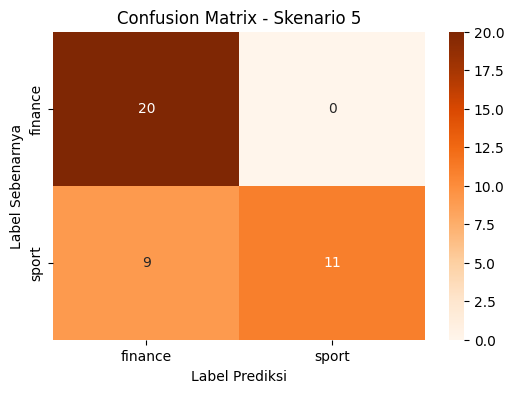

In [ ]:
print("LAPORAN KLASIFIKASI SKENARIO 5:")
print(f"Akurasi Model : {accuracy_score(y_test_s5, y_pred_s5) * 100:.2f}%\n")
print(classification_report(y_test_s5, y_pred_s5))

cm5 = confusion_matrix(y_test_s5, y_pred_s5)
plt.figure(figsize=(6, 4))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Oranges', # Menggunakan warna Oranges agar beda dengan Skenario 1 (Blues)
            xticklabels=nb_final_s5.classes_,
            yticklabels=nb_final_s5.classes_)
plt.title('Confusion Matrix - Skenario 5')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

In [ ]:
# Pilih indeks berita yang ingin dilihat (misal: dokumen ke-101 / indeks 101)
idx = 101

print(f"=== INFORMASI DOKUMEN KE-{idx} (SKENARIO 5) ===")
# Memanggil label dari variabel final Skenario 5
print(f"Kategori : {y_df_final_s5.iloc[idx]}")

# Memanggil jumlah dan sampel token dari kolom token Skenario 5
print(f"Jumlah Token : {len(df_all['token_skenario_5'].iloc[idx])} kata")
print(f"Sampel Token : {df_all['token_skenario_5'].iloc[idx][:10]}...\n")

# Mengambil baris vektor dari DataFrame X final Skenario 5
vektor_dokumen = X_df_final_s5.iloc[idx].values

print(f"Bentuk Vektor (Shape) : {vektor_dokumen.shape}")
print(f"Representasi Vektor ({len(vektor_dokumen)} Dimensi):")
print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 5) ===
Kategori : finance
Jumlah Token : 332 kata
Sampel Token : ['ketua', 'badan', 'lindung', 'konsumen', 'nasional', 'bpkn', 'mufti', 'mubarok', 'minta', 'perintah']...

Bentuk Vektor (Shape) : (75,)
Representasi Vektor (75 Dimensi):
[ 6.2434014e-02 -7.1359962e-02 -1.1363843e-01 -2.3856756e-01
 -3.0218562e-01 -6.6264696e-02 -5.9354454e-02  8.7889090e-02
  4.9072787e-02  2.9998937e-01 -1.3616799e-01 -1.3893688e-01
 -8.1117027e-02  6.5840324e-03 -2.2799715e-01 -2.9667306e-01
  2.3125915e-01 -2.4393904e-01 -1.9875552e-01 -1.5139207e-01
 -2.2890937e-01  4.5326972e-01  1.4297814e-04  4.6081015e-01
  1.9298053e-01 -5.3637344e-02 -2.1234821e-01 -4.1061756e-01
  1.1231251e-01 -1.1087142e-01  9.8162487e-02 -4.2865849e-01
 -7.9439200e-02  1.8951297e-02  1.3513872e-02  6.8814992e-03
  6.8523504e-02 -3.9732957e-01  9.2063369e-03 -5.4283970e-04
 -1.0534174e-01  7.7564575e-02  3.2254696e-01 -2.9770255e-01
  8.5933976e-02 -1.8948986e-01  2.3327272e-02  1.43992

### Inspeksi Representasi Dokumen

Sel inspeksi memilih dokumen pada indeks `101` (indeks Python dimulai dari nol), lalu menampilkan kategori sebenarnya, jumlah token, sampel token, bentuk vektor, dan nilai fitur embedding. Langkah ini membantu menghubungkan teks yang telah diproses dengan satu vektor dokumen yang masuk ke classifier. Vektor berdimensi `best_vN` tidak dapat dibaca sebagai daftar kata; nilainya adalah rata-rata komponen embedding dari token dokumen.

## **Perbandingan Lima Skenario**

Kode menggabungkan lima tabel tuning, menambahkan nama skenario, mengurutkan semua kombinasi berdasarkan accuracy, lalu menampilkan sepuluh baris teratas. Kolom `Vector_Size`, `Window`, dan `Var_Smoothing` menunjukkan konfigurasi tiap baris. Tabel ini berguna untuk membandingkan hasil percobaan, tetapi konfigurasi terbaik sebaiknya dipilih dengan validasi yang tidak sekaligus digunakan sebagai test akhir.

Saat membaca tabel, periksa label skenario bersama konfigurasi preprocessing. Skenario 5 mempertahankan angka dan stopword, sedangkan skenario 3 menghapus angka tetapi mempertahankan stopword. Interpretasi akhir harus merujuk ke output tabel hasil eksekusi; notebook ini tidak menetapkan pemenang tanpa melihat angka tersebut.

In [ ]:
# 1. Menambahkan kolom penanda pada masing-masing hasil tabel
hasil_tuning_skenario_1['Skenario'] = 'Skenario 1 (Tanpa Angka)'
hasil_tuning_skenario_2['Skenario'] = 'Skenario 2 (Dengan Angka)'
hasil_tuning_skenario_3['Skenario'] = 'Skenario 3 (Tanpa Stopword)'
hasil_tuning_skenario_4['Skenario'] = 'Skenario 4 (Tanpa Stemming)'
hasil_tuning_skenario_5['Skenario'] = 'Skenario 5 (Dengan Stopword dan Angka)'

# 2. Menggabungkan kedua tabel secara vertikal
df_komparasi = pd.concat([hasil_tuning_skenario_1, hasil_tuning_skenario_2, hasil_tuning_skenario_3, hasil_tuning_skenario_4, hasil_tuning_skenario_5], ignore_index=True)

# 3. Merapikan urutan kolom agar nama skenario berada di paling depan
df_komparasi = df_komparasi[['Skenario', 'Vector_Size', 'Window', 'Var_Smoothing', 'Akurasi']]

# 4. Mengurutkan berdasarkan Akurasi dari yang paling tinggi ke rendah
df_komparasi_terurut = df_komparasi.sort_values(by='Akurasi', ascending=False).reset_index(drop=True)

print("=== KOMPARASI KESELURUHAN SKENARIO 1 VS SKENARIO 2 VS SKENARIO 3 ===")
# Menampilkan 10 kombinasi terbaik dari keseluruhan eksperimen
display(df_komparasi_terurut.head(10))

=== KOMPARASI KESELURUHAN SKENARIO 1 VS SKENARIO 2 VS SKENARIO 3 ===


,Skenario,Vector_Size,Window,Var_Smoothing,Akurasi
0,Skenario 2 (Dengan Angka),50,7,1.000000e-09,0.850
1,Skenario 2 (Dengan Angka),50,7,1.000000e-05,0.850
2,Skenario 1 (Tanpa Angka),50,3,1.000000e-09,0.825
3,Skenario 1 (Tanpa Angka),50,3,1.000000e-05,0.825
4,Skenario 2 (Dengan Angka),50,3,1.000000e-05,0.800
5,Skenario 1 (Tanpa Angka),50,5,1.000000e-05,0.800
6,Skenario 1 (Tanpa Angka),50,5,1.000000e-09,0.800
7,Skenario 2 (Dengan Angka),75,7,1.000000e-05,0.800
8,Skenario 4 (Tanpa Stemming),75,5,1.000000e-05,0.800
9,Skenario 4 (Tanpa Stemming),75,3,1.000000e-05,0.800


## **Simpulan dan Catatan Review**

Pipeline pada notebook ini dimulai dari artikel scraping, preprocessing lima konfigurasi, pelatihan embedding Skip-gram, mean pooling untuk membentuk vektor dokumen, tuning `vector_size`, `window`, dan `var_smoothing`, lalu klasifikasi dengan Gaussian Naive Bayes. CBOW dijelaskan sebagai pembanding konsep, sedangkan eksperimen kode menggunakan Skip-gram.

Setiap skenario menguji pilihan preprocessing yang berbeda. Gunakan tabel komparasi dan laporan evaluasi aktual untuk menyatakan konfigurasi mana yang memperoleh accuracy tertinggi pada eksperimen ini. Accuracy bukan satu-satunya ukuran: precision, recall, F1, dan confusion matrix menunjukkan jenis kesalahan serta performa per kelas. Jangan menyimpulkan angka metrik atau pemenang skenario yang tidak ditunjukkan oleh output.

**Catatan metodologis dan saran review (tidak mengubah kode):**

- Fungsi tuning melatih Word2Vec sebelum pembagian train/test dan memilih kombinasi berdasarkan accuracy pada pembagian test yang sama. Tahap modeling final juga membentuk embedding dari seluruh korpus sebelum split. Untuk estimasi yang lebih independen, pisahkan data lebih awal, latih embedding hanya pada training, gunakan validation/cross-validation untuk tuning, dan sisihkan test akhir sampai pemilihan model selesai.
- Komentar pada beberapa pemanggilan tuning menyebut dua nilai untuk `vector_size` dan `window`, padahal masing-masing list berisi tiga nilai: 50, 75, 100 dan 3, 5, 7.
- Komentar preprocessing Skenario 3 dan 4 tidak seluruhnya sesuai dengan argumen fungsi. Tabel skenario di atas mengikuti nilai aktual `hapus_angka`, `hapus_stopword`, dan `pakai_stemming` dalam kode.
- Tabel komparasi memberi label Skenario 5 sebagai “Dengan Stopword dan Angka”; artinya kedua jenis token dipertahankan. Penamaan yang lebih eksplisit dapat mencegah salah baca.
- Pesan judul yang dicetak oleh blok komparasi menyebut Skenario 1 sampai 3, meskipun tabel yang digabungkan dan diurutkan berisi kelima skenario.
- Bagian ekspor model hanya menyediakan pilihan Skenario 1 dan 2, walaupun tuning dan pemodelan mencakup lima skenario.
- Mean pooling menghilangkan urutan kata. Korpus yang terbatas serta `min_count=1` juga dapat membuat embedding kata langka kurang stabil.

Catatan ini menjelaskan batas eksperimen dan potensi penyempurnaan. Sel kode tidak diubah.

In [50]:
import joblib

## **Ekspor Model untuk Digunakan Kembali**

Sel penyimpanan memilih artefak berdasarkan `pilihan_skenario`: opsi 1 menyimpan model Word2Vec lengkap, KeyedVectors, dan Gaussian Naive Bayes Skenario 1; opsi 2 menyimpan model Word2Vec dan Gaussian Naive Bayes Skenario 2. `Word2Vec.save` menyimpan model embedding, `wv.save` menyimpan vocabulary beserta vektor kata, dan `joblib.dump` menyimpan classifier.

Notebook saat ini menjalankan tuning lima skenario, tetapi blok ekspor hanya menyediakan pilihan 1 atau 2. Untuk menggunakan model tersimpan pada aplikasi, preprocessing input baru harus mengikuti konfigurasi skenario yang sama dan kata input harus ditangani sesuai vocabulary embedding.

In [51]:
pilihan_skenario = 1  # Ganti angka ini jika ingin menyimpan skenario lain

if pilihan_skenario == 1:
    print("\nMenyimpan model dari Skenario 1...")
    # 1. Simpan Model Skip-gram Skenario 1 (Gunakan variabel yang benar: model_w2v_final_s1)
    model_w2v_final_s1.save("w2v_skenario1_final.model")
    model_w2v_final_s1.wv.save("w2v_skenario1_vectors.kv")
    
    
    # 2. Simpan Model Naive Bayes Skenario 1 (Gunakan variabel yang benar: nb_final_s1)
    joblib.dump(nb_final_s1, "naive_bayes_skenario1.pkl")
    
    print("Berhasil! Model Skip-gram dan Naive Bayes Skenario 1 telah disimpan.")

elif pilihan_skenario == 2:
    print("\nMenyimpan model dari Skenario 2...")
    # Pastikan skenario 2 sudah dijalankan sebelum memilih opsi ini
    model_w2v_final_s2.save("w2v_skenario2_final.model")
    joblib.dump(nb_final_s2, "naive_bayes_skenario2.pkl")
    
    print("Berhasil! Model Skip-gram dan Naive Bayes Skenario 2 telah disimpan.")

else:
    print("\nPilihan tidak valid. Masukkan angka 1 atau 2.")


Menyimpan model dari Skenario 1...
Berhasil! Model Skip-gram dan Naive Bayes Skenario 1 telah disimpan.


## **Demo Streamlit**

Notebook menautkan aplikasi klasifikasi berita berbasis Streamlit sebagai demo terpisah dari eksperimen dan evaluasi di atas. Aplikasi tersebut dapat dicoba melalui tautan berikut; ketersediaan dan status deploy-nya perlu diperiksa langsung saat digunakan.

[ Buka aplikasi klasifikasi berita di Streamlit ](https://ppw-klasifikasi-berita-hwdef5dzrachrlo7v4s8zm.streamlit.app/)